# 1.4.4 Smoothing Images

## Kernel Convolution

In [55]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [56]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [57]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [58]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [59]:
img

array([[7, 9, 1, 7, 2, 2, 8, 8, 9, 6, 1, 7],
       [1, 9, 8, 4, 2, 4, 5, 8, 8, 9, 2, 9],
       [8, 0, 7, 5, 3, 7, 3, 8, 9, 4, 8, 0],
       [1, 9, 7, 1, 2, 7, 8, 8, 6, 3, 4, 9],
       [7, 2, 4, 7, 6, 1, 4, 3, 1, 9, 3, 6],
       [6, 2, 6, 3, 0, 5, 5, 3, 4, 8, 3, 8],
       [9, 9, 0, 2, 2, 2, 3, 9, 6, 7, 1, 8],
       [9, 5, 7, 2, 0, 1, 7, 8, 3, 3, 6, 2],
       [0, 0, 3, 9, 8, 8, 0, 9, 3, 2, 2, 4],
       [4, 5, 6, 3, 6, 3, 9, 9, 4, 4, 3, 0],
       [1, 9, 5, 6, 5, 6, 4, 7, 3, 8, 6, 2],
       [7, 0, 1, 9, 9, 9, 0, 5, 4, 7, 7, 0]])

In [60]:
h,w=img.shape

In [61]:
print(h,w)

12 12


In [62]:
#[*range(-2,3)]

In [63]:
dst = np.zeros((h,w),dtype = int)

# dst = np.zeros((h,w), np.int64)

In [64]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [65]:
img

array([[7, 9, 1, 7, 2, 2, 8, 8, 9, 6, 1, 7],
       [1, 9, 8, 4, 2, 4, 5, 8, 8, 9, 2, 9],
       [8, 0, 7, 5, 3, 7, 3, 8, 9, 4, 8, 0],
       [1, 9, 7, 1, 2, 7, 8, 8, 6, 3, 4, 9],
       [7, 2, 4, 7, 6, 1, 4, 3, 1, 9, 3, 6],
       [6, 2, 6, 3, 0, 5, 5, 3, 4, 8, 3, 8],
       [9, 9, 0, 2, 2, 2, 3, 9, 6, 7, 1, 8],
       [9, 5, 7, 2, 0, 1, 7, 8, 3, 3, 6, 2],
       [0, 0, 3, 9, 8, 8, 0, 9, 3, 2, 2, 4],
       [4, 5, 6, 3, 6, 3, 9, 9, 4, 4, 3, 0],
       [1, 9, 5, 6, 5, 6, 4, 7, 3, 8, 6, 2],
       [7, 0, 1, 9, 9, 9, 0, 5, 4, 7, 7, 0]])

In [66]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  18,  11,  -6,  -5,   0,  -3,   3,  -3,  16, -19,   0],
       [  0, -33,   8,   5,  -4,  11, -16,   4,  10, -13,  22,   0],
       [  0,  26,   7, -17,  -9,  10,  10,   7,   3, -11,  -7,   0],
       [  0, -14,  -6,  14,  14, -18,  -1,  -4, -18,  21, -10,   0],
       [  0, -15,  15,  -3, -16,  12,   5,  -9,  -2,   9,  -8,   0],
       [  0,  20, -24,   1,   4,  -3, -11,  16,   1,  10, -20,   0],
       [  0,  -5,  18, -10, -13, -13,  16,   4,  -8,  -6,  16,   0],
       [  0, -13, -10,  20,   9,  20, -33,  16,  -6,  -4,  -7,   0],
       [  0,   1,   8, -15,   5, -17,  20,   7,  -3,  -1,   0,   0],
       [  0,  25,  -2,   2,  -7,   3,  -6,   7, -11,  12,   4,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [67]:
img = cv2.imread('lena.png', 0)

In [68]:
h,w=img.shape

In [69]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [70]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [71]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [79]:
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

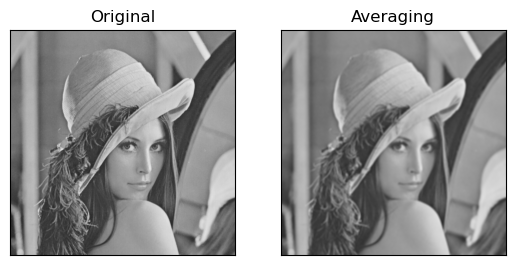

In [80]:
kernel = np.ones((5,5),np.float32)/25
dst = cv2.filter2D(img,-1,kernel)

plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

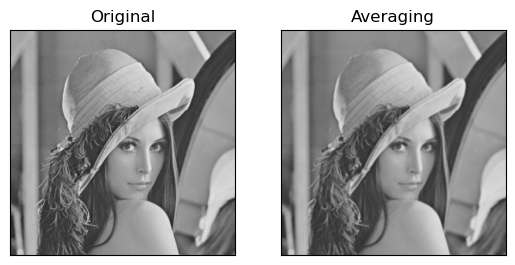

In [81]:
kernel = np.ones((5,5),np.float32)/25
blur = cv2.GaussianBlur(img,(5,5),0)

plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

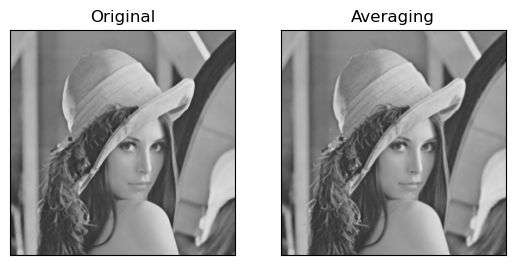

In [83]:
median = cv2.medianBlur(img,5)
kernel = np.ones((5,5),np.float32)/25
blur = cv2.GaussianBlur(img,(5,5),0)

plt.subplot(121),plt.imshow(median),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()